In [14]:
#import modules and load the data
import pandas as pd
import sklearn
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute


df = pd.read_csv("insurance.csv")
print(df)


      age     sex     bmi  children smoker     region      charges  death
0      19  female  27.900         0    yes  southwest  16884.92400      0
1      18    male  33.770         1     no  southeast   1725.55230      0
2      28    male  33.000         3     no  southeast   4449.46200      0
3      33    male  22.705         0     no  northwest  21984.47061      0
4      32    male  28.880         0     no  northwest   3866.85520      0
...   ...     ...     ...       ...    ...        ...          ...    ...
1333   50    male  30.970         3     no  northwest  10600.54830      0
1334   18  female  31.920         0     no  northeast   2205.98080      0
1335   18  female  36.850         0     no  southeast   1629.83350      0
1336   21  female  25.800         0     no  southwest   2007.94500      0
1337   61  female  29.070         0    yes  northwest  29141.36030      0

[1338 rows x 8 columns]


In [5]:
#Prepare the data
df = df.dropna() #remove missings
y = df['charges'] #select Target
X = df.drop('charges',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) #Turn sex, smoker, region, and death into dummy variables


In [9]:
#Prediction with all features
#define the cross-validation

#predict with linear regression
lm = LinearRegression()
lmscores = cross_val_score(lm, X, y, #these define the type of model, features, and target
                           scoring='neg_mean_absolute_error', #test using mean absolute deviation
                           cv=5) #use cross-validation with 5 folds


lmMAE = mean(absolute(lmscores)) #Calculate the overall mean absolute error
print('the average prediction error with full data is: %.0f' % lmMAE) #Print the result

the average prediction error with full data is: 4188


In [15]:
lm = LinearRegression()
Xnosex = X.drop('sex_male',axis=1) #drop sex from the features
lmscores = cross_val_score(lm, Xnosex, y, #these define the type of model, features, and target
                           scoring='neg_mean_absolute_error', #test using mean absolute deviation
                           cv=5) #use cross-validation with 5 folds
lmMAE = mean(absolute(lmscores)) #Calculate the overall mean absolute error
print('the average prediction error with data without sex is: %.0f' % lmMAE) #Print the result

the average prediction error with data without sex is: 4187


In [ ]:
#prepare the data
from sklearn.preprocessing import MinMaxScaler

y= ['death'] #select Target
X = titanic.drop('survived',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True)

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

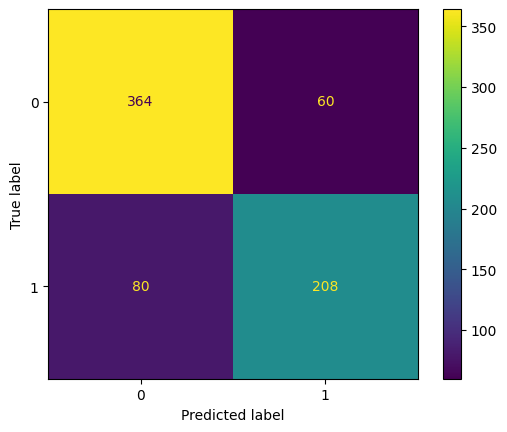

Accuracy: 0.8033707865168539
Precision: 0.7761194029850746
Recall: 0.7222222222222222
F1 Score: 0.7482014388489209


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

logreg = LogisticRegression() #Define the logistic regression function
y_pred = cross_val_predict(logreg, X, y, cv=5) #make the prediction with 5 folds

cm = confusion_matrix(y, y_pred) #Create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

#calculate metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

#print the metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)